# Projektaufgabe: <Titel>

**Vorlesung:** Innovative Konzepte zur Programmierung von Industrierobotern  
**Dozent:** Prof. Dr.-Ing. Björn Hein  
**Gruppe:** <Namen>  
**Aufgabe:** <Nummer und Titel>  
**Abgabedatum:** <Datum>  
**Vortragsdatum:** <Datum>

## 1. Kurzfassung

Fassen Sie kurz Problem, Ansatz, wichtigste Ergebnisse und offene Punkte zusammen.

## 2. Zielsetzung

Beschreiben Sie die konkrete Aufgabenstellung, eigene Teilziele und experimentelle Fragestellungen.

## 3. Ausgangscode und verwendete Module

Dokumentieren Sie verwendete Module, erweiterte Klassen/Funktionen, neue Module und den Startpunkt der eigenen Lösung.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOKS_DIR))

REPO_ROOT

WindowsPath('c:/Users/vendo/Desktop/Uni/Semester 3/Innovative Konzepte zur Programmierung von Industrierobotern/Projekt/intro-path-planning')

## 4. Konzept und Algorithmus

Beschreiben Sie den Algorithmus fachlich. Nutzen Sie Skizzen, Pseudocode, Tabellen oder kurze Formeln, wenn sie helfen.

## 5. Implementierung

Erläutern Sie die wichtigsten Implementierungsentscheidungen. Umfangreicher Code soll in Modulen liegen und hier importiert werden.

In [2]:
# Eigene Module importieren
# Beispiel:
# from my_planner import MyPlanner

pass

[np.str_('start'), np.str_('9'), np.str_('6'), np.str_('11'), np.str_('0'), np.str_('8'), np.str_('goal_0'), np.str_('8'), np.str_('0'), np.str_('11'), np.str_('6'), np.str_('9'), np.str_('start')]
ERROR:  Trap name 'Gsp' is not defined
C:\Users\vendo\AppData\Local\Temp\ipykernel_29800\564467660.py 31 <module>
c:\Users\vendo\Desktop\Uni\Semester 3\Innovative Konzepte zur Programmierung von Industrierobotern\Projekt\intro-path-planning\src\multiquery\MultiqueryPRMVisualize.py 42 multiqueryPRMVisualize
ERROR:  Bottleneck [0 1 2 2 2], 2, [0, 1]
C:\Users\vendo\AppData\Local\Temp\ipykernel_29800\564467660.py 24 <module>
c:\Users\vendo\Desktop\Uni\Semester 3\Innovative Konzepte zur Programmierung von Industrierobotern\Projekt\intro-path-planning\notebooks\IPPerfMonitor.py 29 __call__
c:\Users\vendo\Desktop\Uni\Semester 3\Innovative Konzepte zur Programmierung von Industrierobotern\Projekt\intro-path-planning\src\multiquery\MultiQueryRoundtripPlanner.py 33 planPath
c:\Users\vendo\Desktop\Uni\

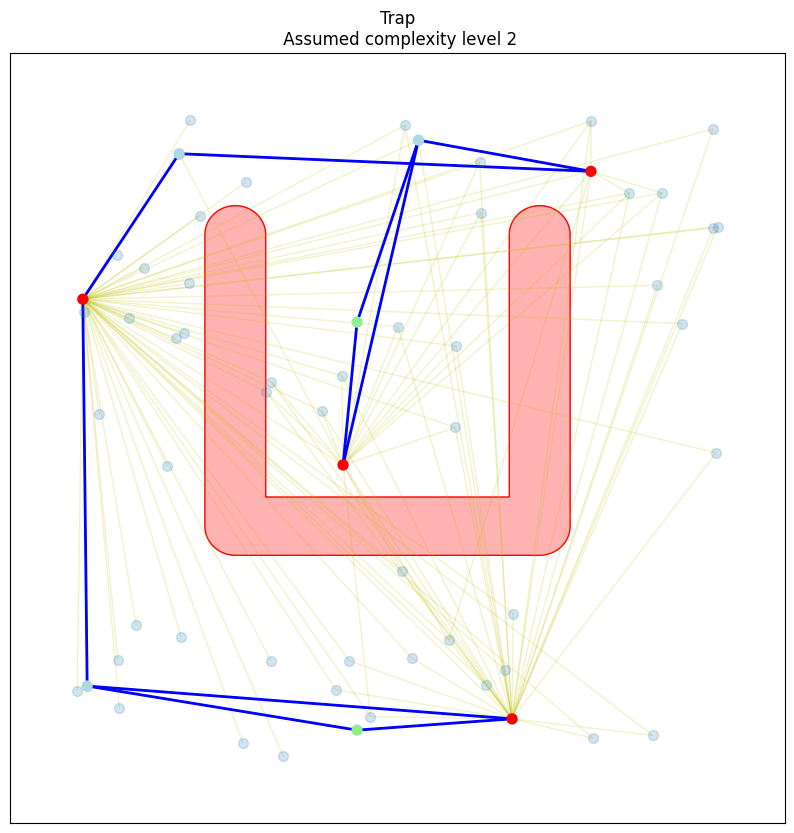

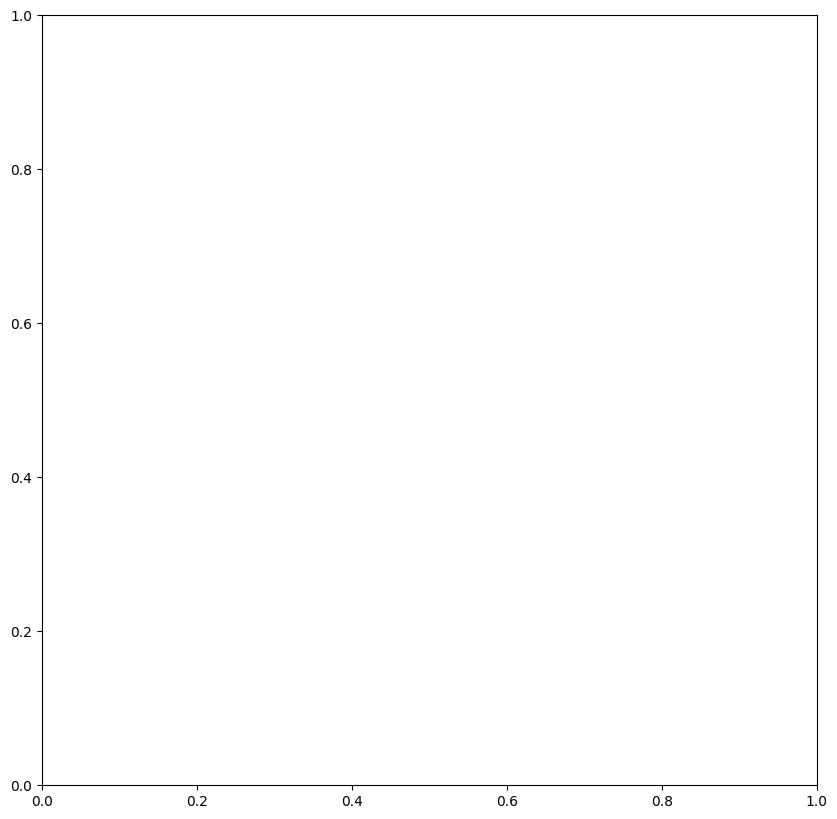

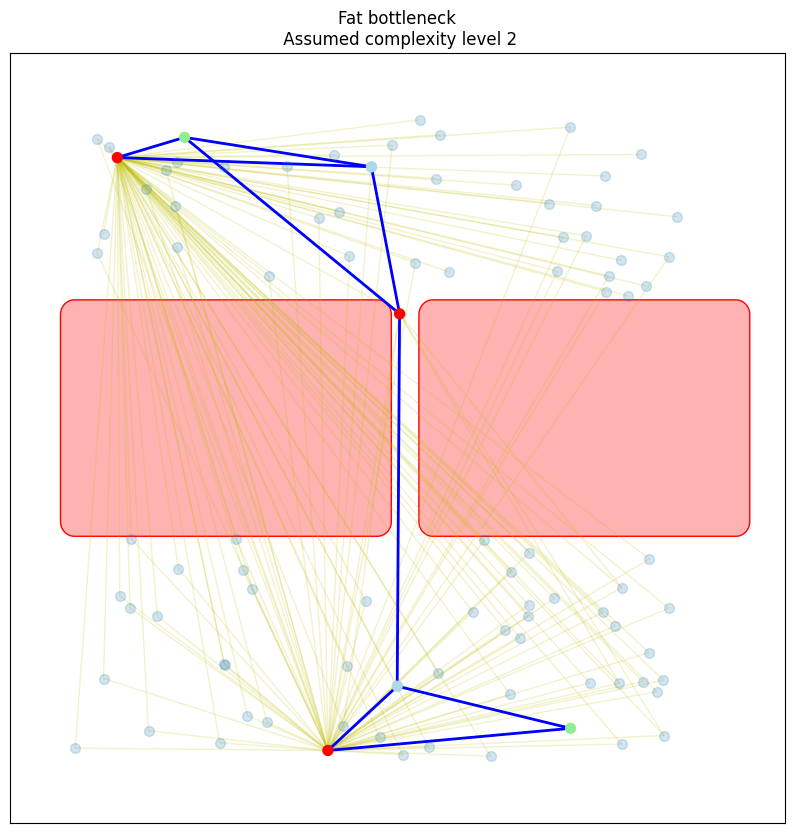

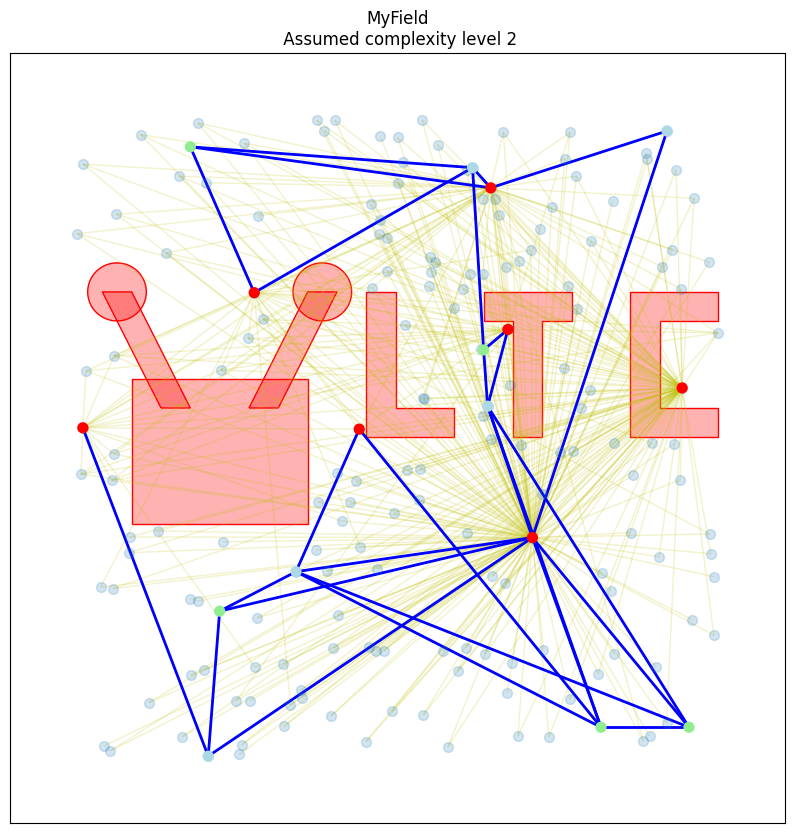

In [3]:
import traceback

from IPVISVisibilityPRM import visibilityPRMVisualize
from src.multiquery.MultiqueryPRMVisualize import multiqueryPRMVisualize

from src.multiquery.VisibilityPRMRoadmapper import VisibilityPRMRoadmapper
from src.multiquery.MultiQueryRoundtripPlanner import MultiQueryRoundtripPlanner

import src.benchmarking.RoundtripTestSuite as ts

import matplotlib.pylab as plt


visConfig = dict()
visConfig["ntry"] = 50
visConfig["mConnections"] = True
visConfig["directConnections"] = True

for benchmark in ts.benchList:
    try:
        fig_local = plt.figure(figsize=(10,10))
        ax = fig_local.add_subplot(1,1,1)
        planner = MultiQueryRoundtripPlanner(VisibilityPRMRoadmapper(benchmark.collisionChecker), benchmark.collisionChecker)
        solution = planner.planPath(benchmark.startList, benchmark.goalList, visConfig)
        title = benchmark.name
        if solution == []:
            title += " (No path found!)"
        print(solution)
        title += "\n Assumed complexity level " + str(benchmark.level)
        ax.set_title(title)
        multiqueryPRMVisualize(planner, solution, ax=ax, nodeSize=50)
    except Exception as e:
        print("ERROR: ",benchmark.name, e)
        for frame in traceback.extract_tb(e.__traceback__):
            print(frame.filename, frame.lineno, frame.name)

## 6. Validierung an kleinen Beispielen

Zeigen Sie an kleinen, nachvollziehbaren Fällen, dass die zentralen Bausteine korrekt funktionieren.

In [4]:
# Kleine Tests oder Plausibilitaetschecks ausfuehren.
pass

## 7. Experimente und Benchmarks

Beschreiben Sie Testumgebungen, Parameter, Metriken und Anzahl der Wiederholungen.

### 7.1 Benchmarks für den 2-DoF-Punktroboter
Der Punktroboter besitzt die Konfiguration $q=[x,y]$ und damit genau zwei Freiheitsgrade. Für die geforderten drei Fälle werden die Umgebungen **Trap**, **Bottleneck** und **Fat bottleneck** aus den Vorlesungs-Benchmarks wiederverwendet. Die Start- und Zielmengen werden für das Roundtrip-Problem auf mehrere Zielpunkte erweitert.

Zusätzlich werden die in `src.benchmarking.RoundtripTestSuite` definierten Benchmarks **Alternating Gates** und **Escape Chamber** unverändert übernommen. Damit wird der Punktroboter in insgesamt fünf unterschiedlichen Umgebungen getestet.


In [5]:
import numpy as np

from notebooks.IPBenchmark import Benchmark
from notebooks.IPEnvironment import CollisionChecker
from src.benchmarking import RoundtripTestSuite as lecture_benchmarks


def copy_point_environment(lecture_benchmark):
    """Create an independent collision checker from a lecture benchmark."""
    checker = lecture_benchmark.collisionChecker
    return CollisionChecker(
        scene=dict(checker.scene),
        limits=checker.getEnvironmentLimits(),
    )


POINT_ROBOT_BENCHMARKS = [
    Benchmark(
        "PointRobot Trap",
        copy_point_environment(lecture_benchmarks.benchList[0]),
        [[10.0, 15.0]],
        [[10.0, 1.0], [2.0, 20.0], [20.0, 20.0]],
        "Roundtrip from inside the trap to three targets outside it.",
        2,
    ),
    Benchmark(
        "PointRobot Bottleneck",
        copy_point_environment(lecture_benchmarks.benchList[1]),
        [[4.0, 15.0]],
        [[18.0, 1.0], [4.0, 3.0], [18.0, 20.0], [8.0, 18.0]],
        "Roundtrip with targets on both sides of a narrow passage.",
        2,
    ),
    Benchmark(
        "PointRobot Fat Bottleneck",
        copy_point_environment(lecture_benchmarks.benchList[2]),
        [[4.0, 21.0]],
        [[18.0, 1.0], [4.0, 3.0], [18.0, 20.0], [12.0, 4.0]],
        "Roundtrip through an extended narrow passage.",
        3,
    ),
]

# Add the two new RoundtripTestSuite cases without redefining their geometry.
for benchmark_name in ("Alternating Gates", "Escape Chamber"):
    source_benchmark = next(
        benchmark
        for benchmark in lecture_benchmarks.benchList
        if benchmark.name == benchmark_name
    )

    POINT_ROBOT_BENCHMARKS.append(
        Benchmark(
            source_benchmark.name,
            copy_point_environment(source_benchmark),
            [list(configuration) for configuration in source_benchmark.startList],
            [list(configuration) for configuration in source_benchmark.goalList],
            source_benchmark.description,
            source_benchmark.level,
        )
    )


### 7.2 Benchmarks für den PlanarManipulator
Es werden drei Fälle definiert: ein einfacher 2-DoF-Fall, ein schwierigerer 2-DoF-Fall mit mehr Hindernissen und Zielen sowie ein 4-DoF-Fall. Ein fester Zufalls-Seed erzeugt reproduzierbare, kollisionsfreie und ausreichend voneinander entfernte Gelenkkonfigurationen.

In [6]:
from shapely.geometry import LineString

from notebooks.IPEnvironmentKin import KinChainCollisionChecker
from notebooks.IPPlanarManipulator import PlanarRobot


LECTURE_PLANAR_SCENE = {
    "obs1": LineString([(-2.0, 0.0), (-0.8, 0.0)]).buffer(0.5),
    "obs2": LineString([(2.0, 0.0), (2.0, 1.0)]).buffer(0.2),
    "obs3": LineString([(-1.0, 2.0), (1.0, 2.0)]).buffer(0.1),
}


def angular_distance(first, second):
    """Return the wrapped Euclidean distance between joint configurations."""
    difference = np.asarray(first) - np.asarray(second)
    wrapped = (difference + np.pi) % (2.0 * np.pi) - np.pi
    return float(np.linalg.norm(wrapped))


def sample_free_configurations(
    environment,
    number_of_configurations,
    seed,
    minimum_distance=1.2,
    maximum_attempts=20_000,
):
    """Generate deterministic collision-free benchmark configurations."""
    generator = np.random.default_rng(seed)
    configurations = []

    for _ in range(maximum_attempts):
        candidate = generator.uniform(
            low=-np.pi,
            high=np.pi,
            size=environment.getDim(),
        ).tolist()

        if environment.pointInCollision(candidate):
            continue

        if any(
            angular_distance(candidate, existing) < minimum_distance
            for existing in configurations
        ):
            continue

        configurations.append(candidate)

        if len(configurations) == number_of_configurations:
            return configurations

    raise RuntimeError(
        f"Could not generate {number_of_configurations} free configurations."
    )


def create_planar_benchmark(
    name,
    degrees_of_freedom,
    scene,
    number_of_goals,
    seed,
    level,
    description,
):
    """Create a reproducible planar-manipulator roundtrip benchmark."""
    robot = PlanarRobot(n_joints=degrees_of_freedom)
    joint_limits = [[-np.pi, np.pi] for _ in range(degrees_of_freedom)]
    environment = KinChainCollisionChecker(
        robot,
        scene=dict(scene),
        limits=joint_limits,
        fk_resolution=0.15,
    )

    configurations = sample_free_configurations(
        environment,
        number_of_configurations=number_of_goals + 1,
        seed=seed,
    )

    return Benchmark(
        name,
        environment,
        [configurations[0]],
        configurations[1:],
        description,
        level,
    )


PLANAR_ROBOT_BENCHMARKS = [
    create_planar_benchmark(
        name="PlanarRobot 2-DoF Easy",
        degrees_of_freedom=2,
        scene={"obs2": LECTURE_PLANAR_SCENE["obs2"]},
        number_of_goals=3,
        seed=10,
        level=1,
        description="Two-joint planar robot with one workspace obstacle.",
    ),
    create_planar_benchmark(
        name="PlanarRobot 2-DoF Hard",
        degrees_of_freedom=2,
        scene=LECTURE_PLANAR_SCENE,
        number_of_goals=4,
        seed=21,
        level=3,
        description="Two-joint planar robot with the complete lecture scene.",
    ),
    create_planar_benchmark(
        name="PlanarRobot 4-DoF",
        degrees_of_freedom=4,
        scene=LECTURE_PLANAR_SCENE,
        number_of_goals=4,
        seed=42,
        level=3,
        description="Four-joint planar robot in a four-dimensional configuration space.",
    ),
]


benchmarks = POINT_ROBOT_BENCHMARKS + PLANAR_ROBOT_BENCHMARKS

### 7.3 Prüfung der Benchmarkdefinitionen

Vor der Planung werden Dimension und Kollisionsfreiheit aller Start- und Zielkonfigurationen geprüft. Dadurch werden ungültige Benchmarkdaten früh erkannt und nicht fälschlich als Fehler des Roundtrip-Planers gewertet.

In [7]:
def validate_benchmark(benchmark):
    """Validate dimensions and collisions for all important configurations."""
    environment = benchmark.collisionChecker
    configurations = benchmark.startList + benchmark.goalList

    for configuration in configurations:
        if len(configuration) != environment.getDim():
            raise ValueError(
                f"{benchmark.name}: configuration {configuration} has the wrong dimension."
            )

        if environment.pointInCollision(configuration):
            raise ValueError(
                f"{benchmark.name}: configuration {configuration} is in collision."
            )

    return True


for benchmark in benchmarks:
    validate_benchmark(benchmark)
    robot_type = (
        "PlanarManipulator"
        if isinstance(benchmark.collisionChecker, KinChainCollisionChecker)
        else "PointRobot"
    )
    print(
        f"{benchmark.name:30s} | {robot_type:17s} | "
        f"DoF: {benchmark.collisionChecker.getDim()} | "
        f"Goals: {len(benchmark.goalList)}"
    )

PointRobot Trap                | PointRobot        | DoF: 2 | Goals: 3
PointRobot Bottleneck          | PointRobot        | DoF: 2 | Goals: 4
PointRobot Fat Bottleneck      | PointRobot        | DoF: 2 | Goals: 4
PlanarRobot 2-DoF Easy         | PlanarManipulator | DoF: 2 | Goals: 3
PlanarRobot 2-DoF Hard         | PlanarManipulator | DoF: 2 | Goals: 4
PlanarRobot 4-DoF              | PlanarManipulator | DoF: 4 | Goals: 4


## 8. Visualisierungen und Animationen

Zeigen Sie Suchraum, Roadmap/Baum, Pfad, Kollisionen, Statistiken oder Animationen.

In [8]:
# Visualisierungen erzeugen.
pass

### 8.1 Visualisierung der Roundtrip-Ergebnisse
Die vorhandenen Visualisierungsfunktionen aus `IPVISBasicPRM.py`, `IPVISLazyPRM.py` und `IPVISVisibilityPRM.py` werden direkt wiederverwendet. Für den zusammengesetzten Roundtrip wird `basicPRMVisualize` genutzt, da diese Funktion nur den Graphen, die Kollisionsprüfung und den Lösungspfad benötigt.

In [9]:
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from notebooks.IPVISBasicPRM import basicPRMVisualize
from notebooks.IPVISLazyPRM import lazyPRMVisualize
from notebooks.IPVISVisibilityPRM import visibilityPRMVisualize


PLANNER_VISUALIZERS = {
    "BasicPRM": basicPRMVisualize,
    "LazyPRM": lazyPRMVisualize,
    "VisPRM": visibilityPRMVisualize,
}


def _configuration_labels(benchmark):
    """Map start and goal configurations to readable labels."""
    labels = {tuple(np.asarray(benchmark.startList[0], dtype=float)): "S"}
    for index, goal in enumerate(benchmark.goalList, start=1):
        labels[tuple(np.asarray(goal, dtype=float))] = f"G{index}"
    return labels


def _visit_order(planner, solution, benchmark):
    """Extract the visit order from the final graph path."""
    labels = _configuration_labels(benchmark)
    order = []

    for node in solution:
        position = tuple(np.asarray(planner.graph.nodes[node]["pos"], dtype=float))
        label = labels.get(position)
        if label is not None and (not order or order[-1] != label):
            order.append(label)

    return order


def visualize_roundtrip(planner, solution, benchmark):
    """Show the start, goals, selected order, and final combined path."""
    fig, ax = plt.subplots(figsize=(10, 8))
    basicPRMVisualize(planner, solution, ax=ax, nodeSize=45)

    positions = nx.get_node_attributes(planner.graph, "pos")
    labels_by_configuration = _configuration_labels(benchmark)
    important_nodes = {}

    for node, position in positions.items():
        label = labels_by_configuration.get(tuple(np.asarray(position, dtype=float)))
        if label is not None:
            important_nodes[node] = label

    start_nodes = [node for node, label in important_nodes.items() if label == "S"]
    goal_nodes = [node for node, label in important_nodes.items() if label != "S"]

    nx.draw_networkx_nodes(
        planner.graph,
        positions,
        nodelist=start_nodes,
        node_color="#00aa44",
        node_size=240,
        node_shape="*",
        ax=ax,
    )
    nx.draw_networkx_nodes(
        planner.graph,
        positions,
        nodelist=goal_nodes,
        node_color="#e53935",
        node_size=170,
        ax=ax,
    )
    nx.draw_networkx_labels(planner.graph, positions, labels=important_nodes, ax=ax)

    order = _visit_order(planner, solution, benchmark)
    ax.set_title(
        f"{benchmark.name}\nVisit order: " + " → ".join(order),
        fontweight="bold",
    )
    ax.set_aspect("equal", adjustable="box")
    return fig, ax


def visualize_pairwise_paths(roundtrip_planner, visualizer):
    """Show every pairwise path generated by the selected base planner."""
    number_of_paths = len(roundtrip_planner.paths)
    columns = min(3, number_of_paths)
    rows = math.ceil(number_of_paths / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(6 * columns, 5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for index, (planner, path) in enumerate(
        zip(roundtrip_planner.planners, roundtrip_planner.paths)
    ):
        visualizer(planner, path, ax=axes[index], nodeSize=35)
        axes[index].set_title(f"Teilpfad {index + 1}")
        axes[index].set_aspect("equal", adjustable="box")

    for axis in axes[number_of_paths:]:
        axis.set_visible(False)

    fig.tight_layout()
    return fig, axes

### 8.2 Animation der PlanarManipulator-Beispiele

Für die PlanarManipulator-Beispiele wird die vorhandene Funktion `animateSolution` aus `IPEnvironmentKin.py` verwendet. Bei einem 2-DoF-Manipulator zeigt sie den Arbeitsraum und den zweidimensionalen Konfigurationsraum nebeneinander. Für Manipulatoren mit mehr als zwei Freiheitsgraden wird die Roboterbewegung im Arbeitsraum animiert.

Da der Roundtrip-Planer seinen zusammengesetzten Graphen im gleichen Format wie die Vorlesungsplaner speichert, kann der finale Roundtrip direkt an `animateSolution` übergeben werden.

In [10]:
from notebooks.IPEnvironmentKin import KinChainCollisionChecker, animateSolution


def animate_planar_roundtrip(
    roundtrip_planner,
    solution,
    benchmark,
    workspace_limits,
):
    """Animate a complete planar-manipulator roundtrip in the workspace."""
    environment = benchmark.collisionChecker
    if not isinstance(environment, KinChainCollisionChecker):
        raise TypeError("The benchmark must use KinChainCollisionChecker.")

    return animateSolution(
        roundtrip_planner,
        environment,
        solution,
        basicPRMVisualize,
        workSpaceLimits=workspace_limits,
    )

### 8.3 Anwendung auf die Versuchsergebnisse

Nach einem Planungsdurchlauf werden der Roundtrip-Planer, dessen Lösung, der verwendete Benchmark und die zum Basisplaner passende Vorlesungsvisualisierung direkt an die Funktionen übergeben.

In [12]:
# Variables produced by the Task 1 experiment:
# roundtrip_planner = ...
# solution = roundtrip_planner.planPath(benchmark.startList, benchmark.goalList, config)

base_visualizer = PLANNER_VISUALIZERS[roundtrip_planner.plannerClass.__name__]

visualize_roundtrip(roundtrip_planner, solution, benchmark)
visualize_pairwise_paths(roundtrip_planner, base_visualizer)

if isinstance(benchmark.collisionChecker, KinChainCollisionChecker):
    animate_planar_roundtrip(
        roundtrip_planner,
        solution,
        benchmark,
        workspace_limits=[[-5, 5], [-5, 5]],
    )

NameError: name 'roundtrip_planner' is not defined

## 9. Ergebnisse

Stellen Sie Ergebnisse in Tabellen und Diagrammen dar und erklären Sie beobachtete Effekte.

In [7]:
# Ergebnisse als DataFrame/Tabelle/Plot darstellen.
pass

## 10. Diskussion

Diskutieren Sie, was funktioniert hat, wo Grenzen liegen, welche Parameter wichtig sind und wie belastbar die Ergebnisse sind.

## 11. Fazit

Fassen Sie die wichtigsten Erkenntnisse knapp zusammen.

## 12. Verwendung von KI-Werkzeugen

Dokumentieren Sie, wofür KI verwendet wurde, welche Vorschläge übernommen oder verworfen wurden und wie die Korrektheit geprüft wurde.

## 13. Präsentationsnotizen

Notieren Sie die Kernaussagen für die Präsentation: Problem, Ansatz, wichtigste Visualisierung, wichtigste Ergebnisse und wichtigste Erkenntnis.